## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [6]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [7]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [8]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [9]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [10]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [11]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [12]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [13]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [14]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [15]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [16]:
inks_df = inks_df.reset_index(drop=False)

In [17]:
inds_df = inds_df.reset_index(drop=False)

In [18]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [19]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [20]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [21]:
inDKs_df.dropna(inplace=True)

In [22]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [23]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [24]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [25]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [26]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [27]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [28]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [29]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [30]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [31]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [32]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [33]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 29),
        nn.ReLU(),
        nn.Linear(29, 29),
        nn.ReLU(),
        nn.Linear(29, 29))
    def forward(self, x):
        return self.seq(x)

## Training

In [34]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=29, bias=True)
    (1): ReLU()
    (2): Linear(in_features=29, out_features=29, bias=True)
    (3): ReLU()
    (4): Linear(in_features=29, out_features=29, bias=True)
  )
)


In [35]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [36]:
EPOCHS = 100000
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.8784621874491374 test 4.6055456570370845
EPOCH 2:
LOSS train 3.7074994246164956 test 4.49641507646497
EPOCH 3:
LOSS train 3.5612882296244304 test 4.393437312642116
EPOCH 4:
LOSS train 3.639619461695353 test 4.300313421473
EPOCH 5:
LOSS train 3.320231223106384 test 4.213945666455334
EPOCH 6:
LOSS train 3.3236272811889647 test 4.137606002544641
EPOCH 7:
LOSS train 3.1393747409184773 test 4.074585518836358
EPOCH 8:
LOSS train 3.063262764612834 test 4.022480441870527
EPOCH 9:
LOSS train 3.1040717442830403 test 3.9795513367183952
EPOCH 10:
LOSS train 2.927822502454122 test 3.9427791277166477
EPOCH 11:
LOSS train 2.9016249497731526 test 3.9109105109613136
EPOCH 12:
LOSS train 3.004555424054464 test 3.883190616163161
EPOCH 13:
LOSS train 2.834550889333089 test 3.8608209619271583
EPOCH 14:
LOSS train 2.8212444464365642 test 3.841297398041741
EPOCH 15:
LOSS train 2.78351898988088 test 3.8230648326762715
EPOCH 16:
LOSS train 3.0274579366048178 test 3.806668100905591
EPOCH 1

LOSS train 2.4755627314249673 test 3.3325427610959326
EPOCH 134:
LOSS train 2.468704561392466 test 3.3288463127122534
EPOCH 135:
LOSS train 2.43658887942632 test 3.328322052971053
EPOCH 136:
LOSS train 2.3055631438891093 test 3.325834666982324
EPOCH 137:
LOSS train 2.333531308174133 test 3.3237686441752357
EPOCH 138:
LOSS train 2.3086939573287966 test 3.322075306883325
EPOCH 139:
LOSS train 2.4113134264945986 test 3.320543589637331
EPOCH 140:
LOSS train 2.3129731098810833 test 3.3187486017065018
EPOCH 141:
LOSS train 2.331917099157969 test 3.316366779523483
EPOCH 142:
LOSS train 2.457879690329234 test 3.3154007144596265
EPOCH 143:
LOSS train 2.3123387495676675 test 3.3127701960612033
EPOCH 144:
LOSS train 2.304798380533854 test 3.3109332783452348
EPOCH 145:
LOSS train 2.3160478591918947 test 3.3093032287298767
EPOCH 146:
LOSS train 2.318270937601725 test 3.308667663801037
EPOCH 147:
LOSS train 2.2976349155108133 test 3.3061307406527285
EPOCH 148:
LOSS train 2.298791829744975 test 3.304

LOSS train 2.129459277788798 test 3.115034054108658
EPOCH 263:
LOSS train 2.14471466143926 test 3.1143636287924665
EPOCH 264:
LOSS train 2.122314230600993 test 3.112447446763639
EPOCH 265:
LOSS train 2.119551094373067 test 3.1089230438474544
EPOCH 266:
LOSS train 2.113688675562541 test 3.108063629093748
EPOCH 267:
LOSS train 2.2880327065785724 test 3.104751919429001
EPOCH 268:
LOSS train 2.120215121905009 test 3.1031530764779194
EPOCH 269:
LOSS train 2.121851066748301 test 3.100524062340921
EPOCH 270:
LOSS train 2.1059227625528973 test 3.0974339407793483
EPOCH 271:
LOSS train 2.11360924243927 test 3.096365621078212
EPOCH 272:
LOSS train 2.0920523206392923 test 3.094284455613937
EPOCH 273:
LOSS train 2.1199819246927896 test 3.0898109218780547
EPOCH 274:
LOSS train 2.094826316833496 test 3.0888964284064855
EPOCH 275:
LOSS train 2.103118447462718 test 3.087127627962988
EPOCH 276:
LOSS train 2.123583992322286 test 3.084038589126575
EPOCH 277:
LOSS train 2.0868540604909263 test 3.0818689669

LOSS train 1.8856249411900838 test 2.8497926259324666
EPOCH 392:
LOSS train 1.8922749757766724 test 2.8477948368999404
EPOCH 393:
LOSS train 2.019766549269358 test 2.8461227151208535
EPOCH 394:
LOSS train 2.042863440513611 test 2.845926707838016
EPOCH 395:
LOSS train 1.8641729354858398 test 2.8433175544036593
EPOCH 396:
LOSS train 1.8914058446884154 test 2.8419667229318595
EPOCH 397:
LOSS train 1.9043263832728068 test 2.8412359813941683
EPOCH 398:
LOSS train 1.8851498365402222 test 2.8392189419278817
EPOCH 399:
LOSS train 1.8821947813034057 test 2.8383218326199007
EPOCH 400:
LOSS train 1.874559462070465 test 2.8376667891430434
EPOCH 401:
LOSS train 1.8687906861305237 test 2.8369047300076384
EPOCH 402:
LOSS train 1.8706765373547871 test 2.8367109473015706
EPOCH 403:
LOSS train 1.8729705691337586 test 2.835014549872643
EPOCH 404:
LOSS train 1.8897125681241354 test 2.833167586352206
EPOCH 405:
LOSS train 1.855781896909078 test 2.8296391157121024
EPOCH 406:
LOSS train 1.8894129117329916 te

LOSS train 1.7719483931859334 test 2.6840325206379343
EPOCH 521:
LOSS train 1.8923246184984843 test 2.6843393739027515
EPOCH 522:
LOSS train 1.7573487639427186 test 2.679723716493287
EPOCH 523:
LOSS train 1.887933119138082 test 2.679496532402485
EPOCH 524:
LOSS train 1.8777247468630474 test 2.6764654848670615
EPOCH 525:
LOSS train 1.8962443629900614 test 2.6736865559319036
EPOCH 526:
LOSS train 1.769807215531667 test 2.6735894127168516
EPOCH 527:
LOSS train 1.877207883199056 test 2.6728130394427057
EPOCH 528:
LOSS train 1.7954206188519797 test 2.670162386521234
EPOCH 529:
LOSS train 1.7589335083961486 test 2.669586739369801
EPOCH 530:
LOSS train 1.755695144335429 test 2.6672298158393635
EPOCH 531:
LOSS train 1.841922442118327 test 2.667411249478041
EPOCH 532:
LOSS train 1.750550369421641 test 2.662965375004533
EPOCH 533:
LOSS train 1.9125400106112163 test 2.6624941212080775
EPOCH 534:
LOSS train 1.760152006149292 test 2.662967622820018
EPOCH 535:
LOSS train 1.8416576385498047 test 2.66

...

LOSS train 0.6431556224822998 test 1.4756350766628301
EPOCH 99415:
LOSS train 0.5152447084585826 test 1.4233989339422117
EPOCH 99416:
LOSS train 0.517143315076828 test 1.4771540016591487
EPOCH 99417:
LOSS train 0.5157472650210063 test 1.4442077236901776
EPOCH 99418:
LOSS train 0.5163370847702027 test 1.474293702569314
EPOCH 99419:
LOSS train 0.5234798689683279 test 1.4296130759884482
EPOCH 99420:
LOSS train 0.5595053931077322 test 1.4695541613791177
EPOCH 99421:
LOSS train 0.5132499575614929 test 1.4139232855776083
EPOCH 99422:
LOSS train 0.5361751218636831 test 1.432900494778255
EPOCH 99423:
LOSS train 0.5159822901089987 test 1.437993317649663
EPOCH 99424:
LOSS train 0.5142050236463547 test 1.4641484290777897
EPOCH 99425:
LOSS train 0.5109583099683126 test 1.4434486589323166
EPOCH 99426:
LOSS train 0.5186989923318227 test 1.4636007803868247
EPOCH 99427:
LOSS train 0.5179449776808421 test 1.4580410609511547
EPOCH 99428:
LOSS train 0.5117586374282836 test 1.475417617901265
EPOCH 99429:


LOSS train 0.5122517486413319 test 1.458233296207883
EPOCH 99540:
LOSS train 0.5166733245054881 test 1.4509724400798727
EPOCH 99541:
LOSS train 0.5116140524546305 test 1.4499756578533423
EPOCH 99542:
LOSS train 0.5083033581574757 test 1.4516965569291982
EPOCH 99543:
LOSS train 0.512218548854192 test 1.4218276133124503
EPOCH 99544:
LOSS train 0.5244053095579148 test 1.4620270742061037
EPOCH 99545:
LOSS train 0.5194136420885722 test 1.4572047337959086
EPOCH 99546:
LOSS train 0.5057634641726811 test 1.4673697738667206
EPOCH 99547:
LOSS train 0.5138779242833456 test 1.4549105989729396
EPOCH 99548:
LOSS train 0.5088476737340292 test 1.4379651464413905
EPOCH 99549:
LOSS train 0.5146860659122467 test 1.4601303898492215
EPOCH 99550:
LOSS train 0.5123558163642883 test 1.456415425423016
EPOCH 99551:
LOSS train 0.5105405211448669 test 1.470179092331826
EPOCH 99552:
LOSS train 0.5084125677744548 test 1.4286800549436924
EPOCH 99553:
LOSS train 0.5188191294670105 test 1.4616518280050461
EPOCH 99554:

LOSS train 0.5160981198151906 test 1.4583759523743058
EPOCH 99663:
LOSS train 0.5122696022192638 test 1.4503525015213536
EPOCH 99664:
LOSS train 0.5281595349311828 test 1.489373349679121
EPOCH 99665:
LOSS train 0.5256044387817382 test 1.4444517826750165
EPOCH 99666:
LOSS train 0.5224238584438959 test 1.4632901248616585
EPOCH 99667:
LOSS train 0.521527514855067 test 1.452798924861981
EPOCH 99668:
LOSS train 0.5169354557991028 test 1.4415902408923544
EPOCH 99669:
LOSS train 0.5099274178345998 test 1.4663664712560966
EPOCH 99670:
LOSS train 0.5157210767269135 test 1.4528925845681018
EPOCH 99671:
LOSS train 0.5191891252994537 test 1.4462011490310263
EPOCH 99672:
LOSS train 0.5116031348705292 test 1.470342389005188
EPOCH 99673:
LOSS train 0.5068894326686859 test 1.4663106889944084
EPOCH 99674:
LOSS train 0.6350678702195486 test 1.4562043265958258
EPOCH 99675:
LOSS train 0.5175062517325083 test 1.4871911094726429
EPOCH 99676:
LOSS train 0.5428477654854457 test 1.4359828596799702
EPOCH 99677:

LOSS train 0.5274242122968038 test 1.46103046563749
EPOCH 99786:
LOSS train 0.5091132154067357 test 1.491568102059774
EPOCH 99787:
LOSS train 0.5190070807933808 test 1.4713654135340366
EPOCH 99788:
LOSS train 0.5086204320192337 test 1.4736607325635465
EPOCH 99789:
LOSS train 0.5081635514895121 test 1.4268138518028624
EPOCH 99790:
LOSS train 0.5183867116769155 test 1.4694376619104643
EPOCH 99791:
LOSS train 0.5168025573094686 test 1.4449124921028411
EPOCH 99792:
LOSS train 0.5138236343860626 test 1.4729360407777516
EPOCH 99793:
LOSS train 0.515565139055252 test 1.4512073203851903
EPOCH 99794:
LOSS train 0.5133504589398702 test 1.473209223422698
EPOCH 99795:
LOSS train 0.5152566790580749 test 1.433906138020396
EPOCH 99796:
LOSS train 0.5233135958512624 test 1.478119043729752
EPOCH 99797:
LOSS train 0.5115069131056468 test 1.410759208272703
EPOCH 99798:
LOSS train 0.5268738190333049 test 1.4542749639076045
EPOCH 99799:
LOSS train 0.5185966789722443 test 1.4414617005257442
EPOCH 99800:
LOS

LOSS train 0.5193248132864634 test 1.4470589547177033
EPOCH 99909:
LOSS train 0.6328703661759695 test 1.5020547473136003
EPOCH 99910:
LOSS train 0.5152166028817494 test 1.4226095653977824
EPOCH 99911:
LOSS train 0.5208963731924693 test 1.4680661812740885
EPOCH 99912:
LOSS train 0.515027376015981 test 1.440326625246007
EPOCH 99913:
LOSS train 0.5211580534776051 test 1.5108093063329688
EPOCH 99914:
LOSS train 0.6386356016000112 test 1.4368193670490268
EPOCH 99915:
LOSS train 0.5136454006036123 test 1.4624648722848907
EPOCH 99916:
LOSS train 0.514747675259908 test 1.4307740022106323
EPOCH 99917:
LOSS train 0.5093194544315338 test 1.473808138205151
EPOCH 99918:
LOSS train 0.5117980360984802 test 1.4672002642189863
EPOCH 99919:
LOSS train 0.5066580971082052 test 1.4465831224199222
EPOCH 99920:
LOSS train 0.536054786046346 test 1.4423773750647377
EPOCH 99921:
LOSS train 0.5175530801216761 test 1.4445240791254594
EPOCH 99922:
LOSS train 0.5085079967975616 test 1.4636391181244244
EPOCH 99923:


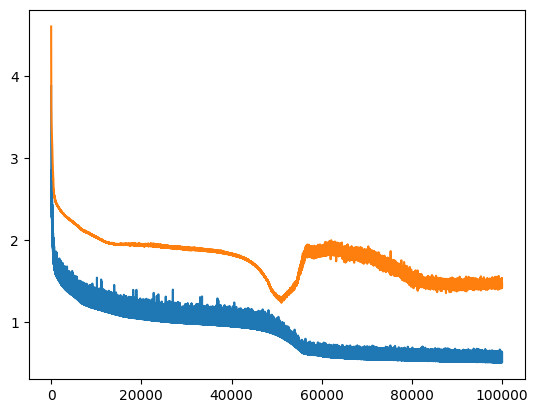

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

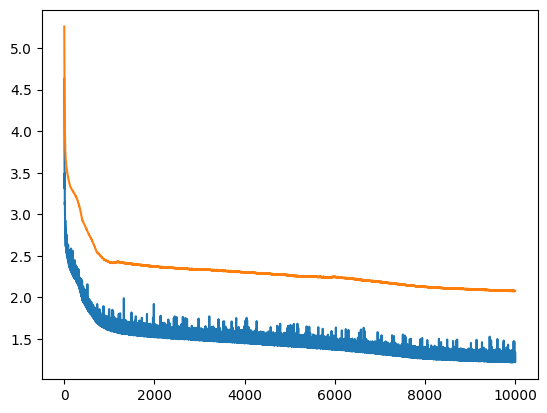

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

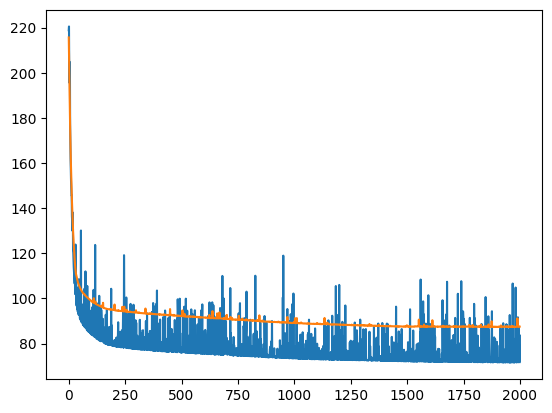

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #all
plt.plot(val_losses) #lr=0.0001

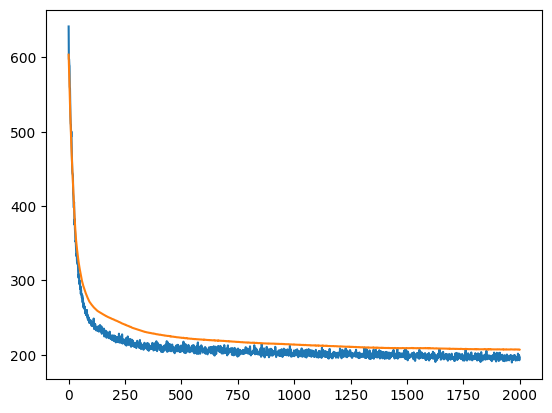

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #simulated
plt.plot(val_losses) #lr=0.0001

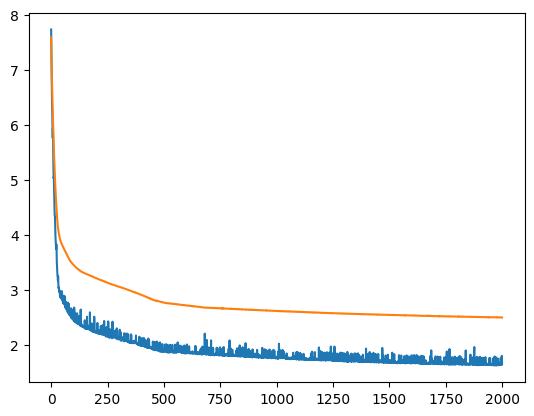

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

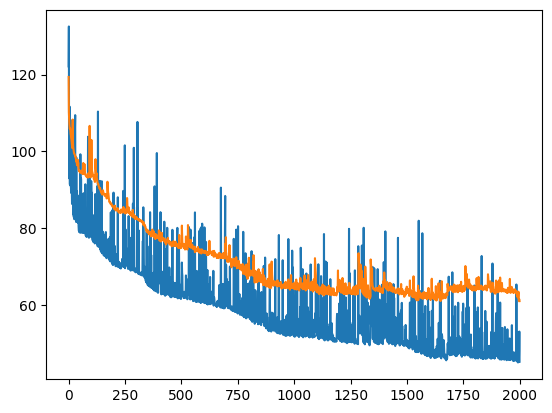

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #all
plt.plot(val_losses) #lr=0.001

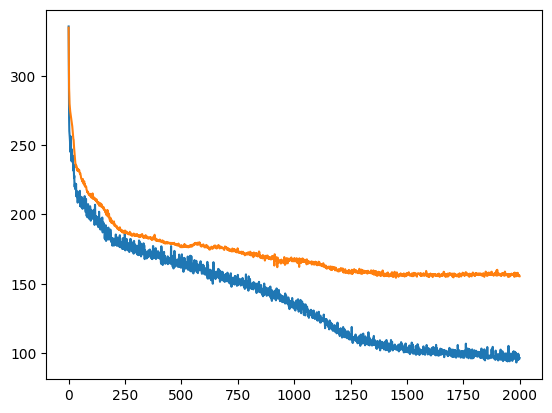

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #simulated
plt.plot(val_losses) #lr=0.001

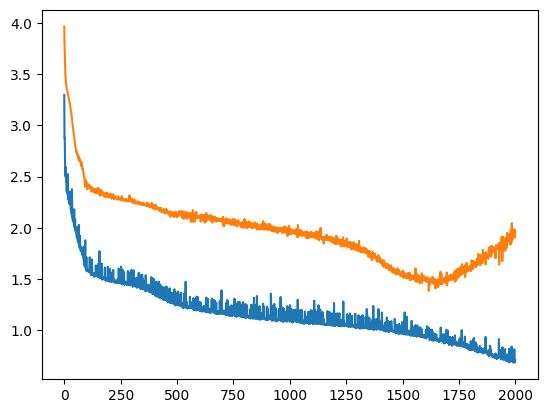

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

## Interpretability